In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
#Loading the dataset, first checking out its path
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [3]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [5]:
print(df.shape)
df.head()
df['label'].value_counts()

(5572, 2)


label
ham     4825
spam     747
Name: count, dtype: int64

In [6]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [7]:
df.head()
df['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [8]:
keywords = ['urgent', 'verify', 'click', 'password', 'bank', 'free', 'win']

def has_keywords(text):
    text = text.lower()
    return int(any(word in text for word in keywords))

df['has_suspicious_words'] = df['message'].apply(has_keywords)

In [9]:
df['has_link'] = df['message'].str.contains('http|www', regex=True).astype(int)

In [10]:
df['message_length'] = df['message'].apply(len)

In [11]:
df.head()

,label,message,has_suspicious_words,has_link,message_length
0,0,"Go until jurong point, crazy.. Available only ...",0,0,111
1,0,Ok lar... Joking wif u oni...,0,0,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1,0,155
3,0,U dun say so early hor... U c already then say...,0,0,49
4,0,"Nah I don't think he goes to usf, he lives aro...",0,0,61


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000)
X_text = vectorizer.fit_transform(df['message']).toarray()

In [13]:
import numpy as np
extra_features = df[['has_suspicious_words', 'has_link', 'message_length']]
X = np.hstack((X_text, extra_features))
y = df['label']

In [14]:
#Training
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [15]:
from sklearn.metrics import classification_report
preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       973
           1       1.00      0.85      0.92       142

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [17]:
def predict_message(msg):
    msg_vec = vectorizer.transform([msg]).toarray()
    
    extra = [[
        has_keywords(msg),
        int(bool(pd.Series(msg).str.contains('http|www', regex=True)[0])),
        len(msg)
    ]]
    
    final_input = np.hstack((msg_vec, extra))
    
    prediction = model.predict(final_input)[0]
    
    return "🚨 Phishing/Spam" if prediction == 1 else "✅ Safe"


print(predict_message("URGENT! Your bank account is blocked. Click here now!"))

✅ Safe


In [18]:
#Accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", accuracy)

Accuracy: 0.9802690582959641


In [19]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
print(cm)


[[973   0]
 [ 22 120]]


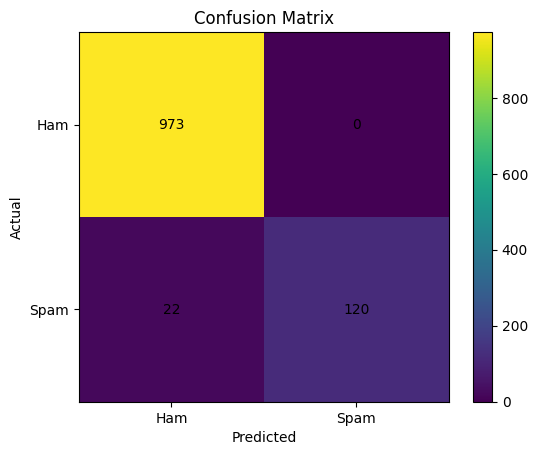

In [20]:
#visualisation
import matplotlib.pyplot as plt

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ['Ham','Spam'])
plt.yticks([0,1], ['Ham','Spam'])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()


In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds))
#cleaner classification report

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       973
           1       1.00      0.85      0.92       142

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



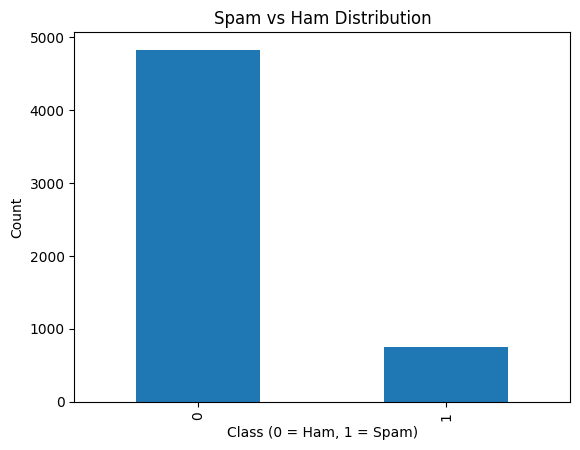

In [22]:
#simpler visual spam vs ham
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

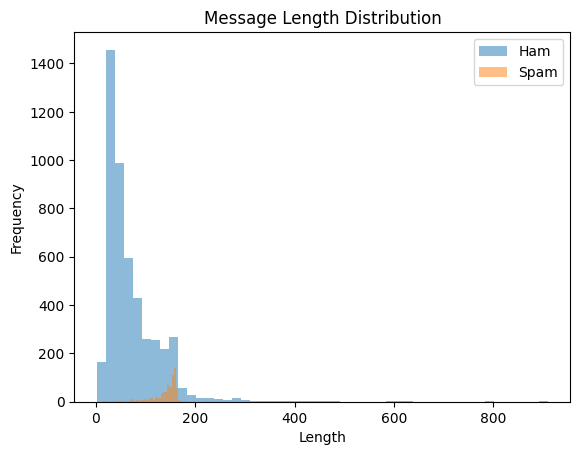

In [23]:
#Msg lenght comparison feature insight
import matplotlib.pyplot as plt

df[df['label']==0]['message_length'].plot(kind='hist', bins=50, alpha=0.5, label='Ham')
df[df['label']==1]['message_length'].plot(kind='hist', bins=50, alpha=0.5, label='Spam')

plt.legend()
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()